`requirements.txt` 

```text
pandas
numpy
lightgbm
catboost
scikit-learn
matplotlib
seaborn
warnings
```

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
TRAIN_PATH = "dataset/train.csv"
TEST_PATH = "dataset/test.csv"

## Define Helper Functions

### Decode GeoHash

In [3]:
__base32 = '0123456789bcdefghjkmnpqrstuvwxyz'
__decodemap = {c: i for i, c in enumerate(__base32)}

In [4]:
def decode_geohash(geohash):

    lat_interval = (-90.0, 90.0)
    lon_interval = (-180.0, 180.0)

    is_even = True

    for c in geohash:

        cd = __decodemap[c]

        for mask in [16, 8, 4, 2, 1]:

            if is_even:

                if cd & mask:
                    lon_interval = ((lon_interval[0] + lon_interval[1]) / 2,lon_interval[1])
                else:
                    lon_interval = (lon_interval[0],(lon_interval[0] + lon_interval[1]) / 2)

            else:
                if cd & mask:
                    lat_interval = ((lat_interval[0] + lat_interval[1]) / 2,lat_interval[1])
                else:
                    lat_interval = (lat_interval[0],(lat_interval[0] + lat_interval[1]) / 2)

            is_even = not is_even

    lat = (lat_interval[0] + lat_interval[1]) / 2
    lon = (lon_interval[0] + lon_interval[1]) / 2

    return lat, lon

### Preprocessing Pipeline

In [5]:
def preprocess(df):

    df = df.copy()

    df[['hour', 'minute']] = (df['timestamp'].str.split(':', expand=True).astype(int))
    df['total_minutes'] = (df['hour'] * 60 + df['minute'])
    df['time_sin'] = np.sin(2 * np.pi * df['total_minutes'] / 1440)
    df['time_cos'] = np.cos(2 * np.pi * df['total_minutes'] / 1440)
    df['day_of_week'] = df['day'] % 7
    df['is_morning_peak'] = (df['hour'].isin([7,8,9])).astype(int)
    df['is_evening_peak'] = (df['hour'].isin([17,18,19,20])).astype(int)


    df['Temperature'] = (df.groupby(['day','hour'])['Temperature'].transform(lambda x: x.fillna(x.median())))
    df['Temperature'] = (df['Temperature'].fillna(df['Temperature'].median()))
    df['RoadType'] = (df['RoadType'].fillna('Unknown'))
    df['Weather'] = (df['Weather'].fillna('Unknown'))

    coords = df['geohash'].apply(decode_geohash)

    df['lat'] = [c[0] for c in coords]
    df['lon'] = [c[1] for c in coords]


    df['geo3'] = df['geohash'].str[:3]
    df['geo4'] = df['geohash'].str[:4]
    df['geo5'] = df['geohash'].str[:5]
    df['geo6'] = df['geohash'].str[:6]


    df['LargeVehicles'] = (df['LargeVehicles'].map({'Allowed':1,'Not Allowed':0}))
    df['Landmarks'] = (df['Landmarks'].map({'Yes':1,'No':0}))

    return df


### Plotting Functions

In [6]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.max_open_warning': 0})

def plot_demand_distribution(df):
    plt.figure(figsize=(14, 5))
    
    plt.subplot(1, 2, 1)
    sns.histplot(df['demand'], bins=50, kde=True, color='blue')
    plt.title('Raw Demand Distribution', fontsize=14, pad=10)
    plt.xlabel('Demand')
    
    plt.subplot(1, 2, 2)
    sns.histplot(np.log1p(df['demand']), bins=50, kde=True, color='green')
    plt.title('Log1p Transformed Demand', fontsize=14, pad=10)
    plt.xlabel('Log(Demand + 1)')
    
    plt.tight_layout()
    plt.show()
    print("Insight: The raw demand is heavily right-skewed. The log transformation normalizes it, justifying our use of np.log1p() during training.\n")

def plot_numeric_correlation(df):
    plt.figure(figsize=(12, 10))

    numeric_cols = df.select_dtypes(include=['int32', 'int64', 'float64']).columns
    corr = df[numeric_cols].corr()
    
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
    plt.title('Numeric Feature Correlation Heatmap', fontsize=16, pad=20)
    plt.show()
    print("Insight: Checks for multicollinearity and shows which engineered numerical features correlate strongest with the target variable.\n")

def plot_median_demand_by_weather_and_road(df):
    plt.figure(figsize=(14, 5))
    
    plt.subplot(1, 2, 1)
    order_weather = df.groupby('Weather')['demand'].median().sort_values(ascending=False).index
    sns.barplot(x='Weather', y='demand', data=df, order=order_weather, errorbar=None, palette='viridis')
    plt.title('Median Demand by Weather', fontsize=12)
    plt.xticks(rotation=45)
    
    plt.subplot(1, 2, 2)
    order_road = df.groupby('RoadType')['demand'].median().sort_values(ascending=False).index
    sns.barplot(x='RoadType', y='demand', data=df, order=order_road, errorbar=None, palette='magma')
    plt.title('Median Demand by Road Type', fontsize=12)
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

def plot_spatial_heatmap(df):
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(df['lon'], df['lat'], c=np.log1p(df['demand']), 
                          cmap='inferno', alpha=0.5, s=10)
    plt.colorbar(scatter, label='Log(Demand)')
    plt.title('Spatial Heatmap of Demand (Geohash Centroids)', fontsize=14, pad=10)
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.show()
    print("Insight: Spatial clustering is highly evident. Specific geographic pockets drive the majority of demand.\n")

def plot_demand_variance_by_hour(df):
    plt.figure(figsize=(12, 5))
    sns.boxplot(x='hour', y='demand', data=df, showfliers=False, palette='coolwarm')
    plt.title('Demand Variance by Hour of Day', fontsize=14, pad=10)
    plt.xlabel('Hour of Day')
    plt.ylabel('Demand (Outliers Removed)')
    plt.show()
    print("Insight: Highlights the clear cyclical nature of demand, validating the creation of time_sin, time_cos, and peak hour flags.\n")

In [7]:
def run_comprehensive_eda(df):
    print("="*50)
    print("STARTING EXPLORATORY DATA ANALYSIS")
    print("="*50)

    plot_demand_distribution(df)

    plot_demand_variance_by_hour(df)

    plot_spatial_heatmap(df)

    plot_median_demand_by_weather_and_road(df)

    plot_numeric_correlation(df)

## Load Data & Run Analysis

In [8]:
print("Loading data...")

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

train_df = preprocess(train)
test_df = preprocess(test)

Loading data...


STARTING EXPLORATORY DATA ANALYSIS


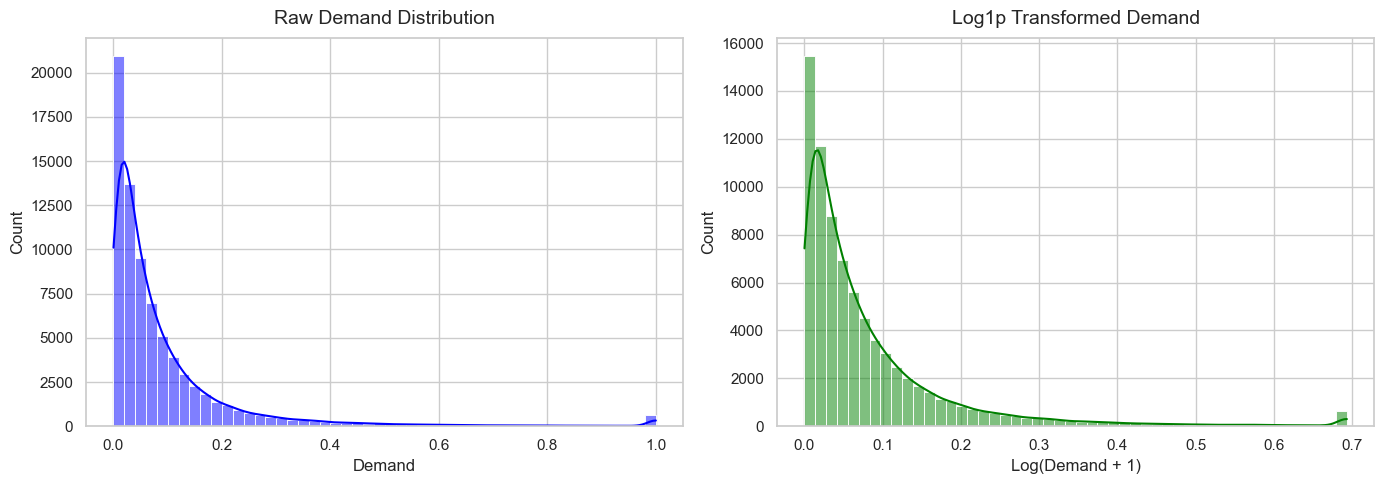

Insight: The raw demand is heavily right-skewed. The log transformation normalizes it, justifying our use of np.log1p() during training.



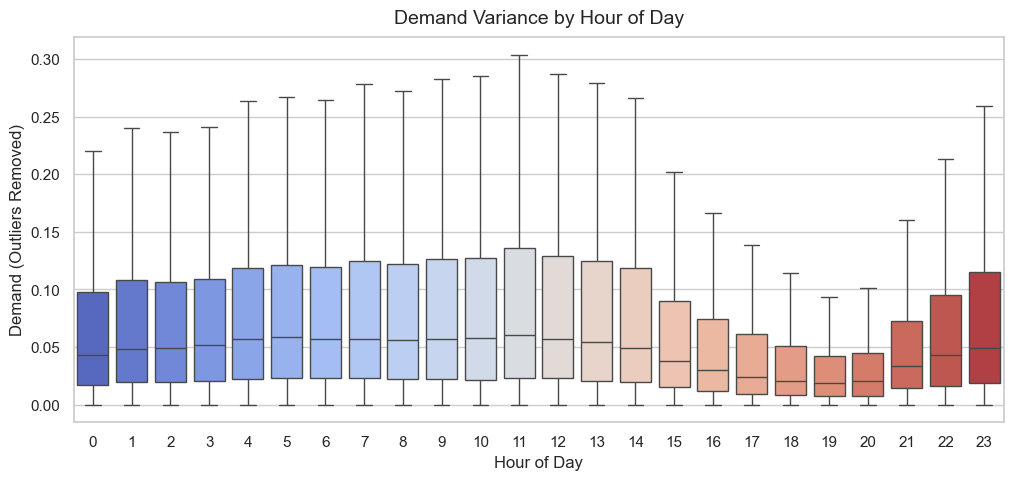

Insight: Highlights the clear cyclical nature of demand, validating the creation of time_sin, time_cos, and peak hour flags.



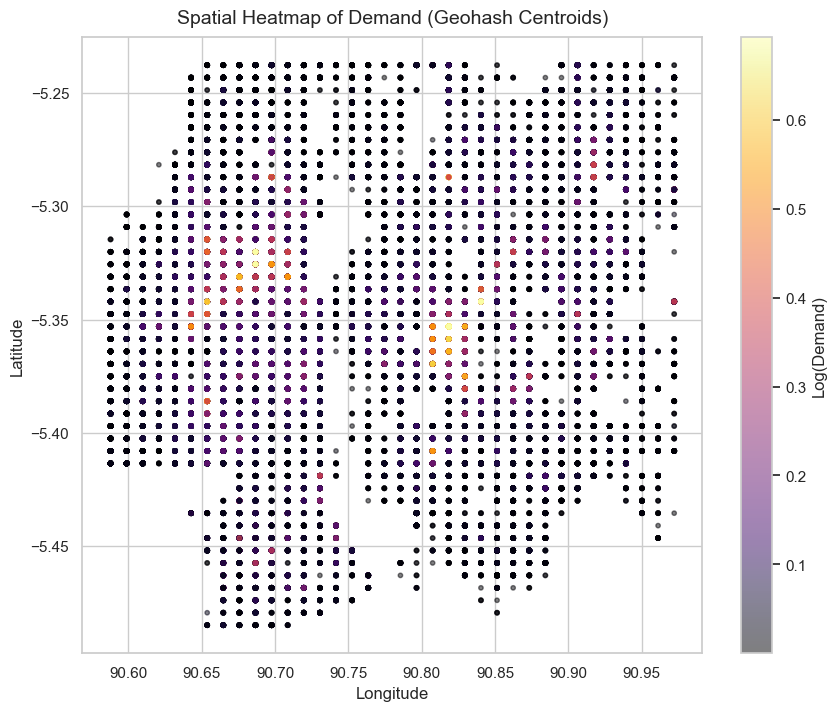

Insight: Spatial clustering is highly evident. Specific geographic pockets drive the majority of demand.



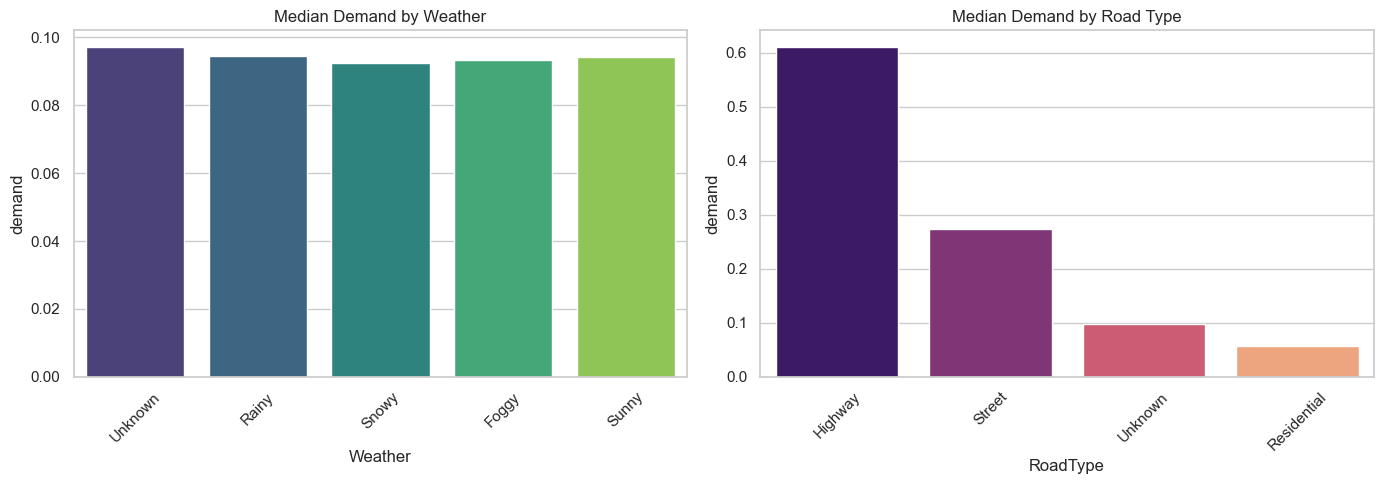

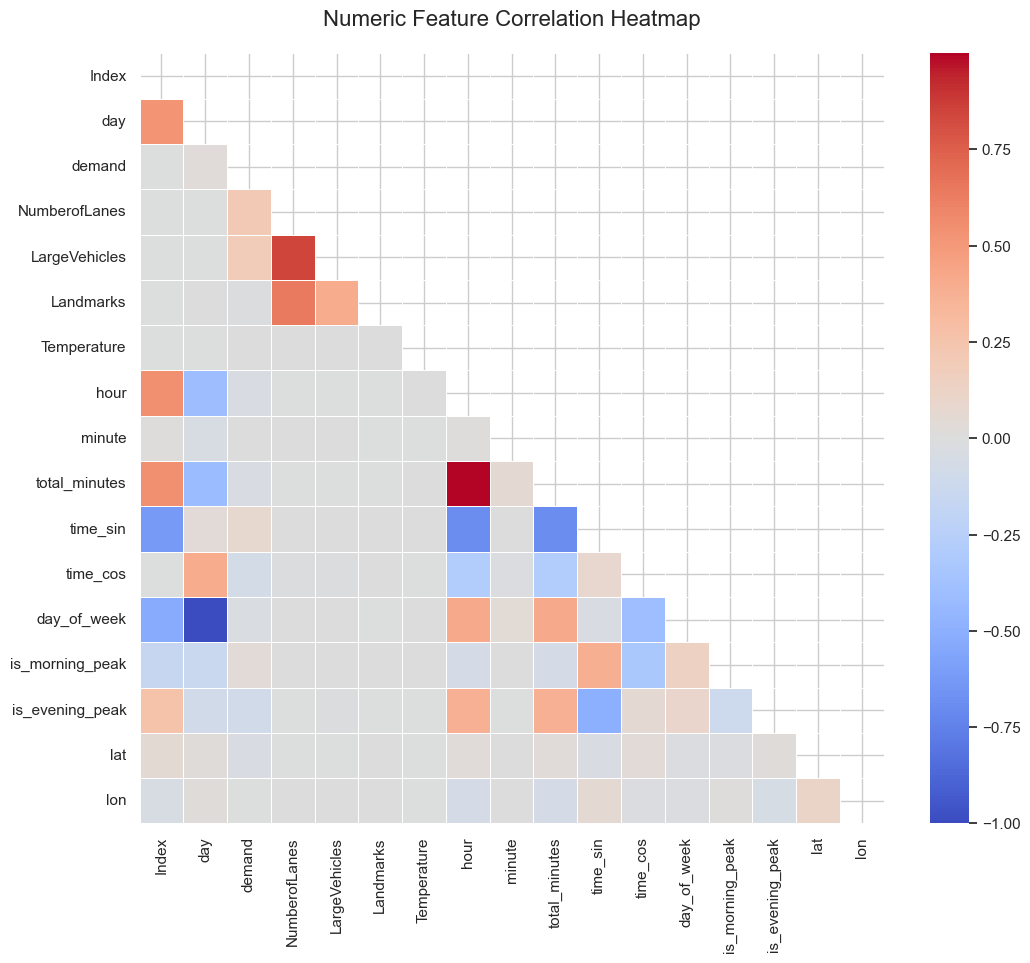

Insight: Checks for multicollinearity and shows which engineered numerical features correlate strongest with the target variable.



In [9]:
run_comprehensive_eda(train_df)

## Training

### Augment Dataset

In [10]:
kf = KFold(n_splits=5,shuffle=True,random_state=42)

global_mean = train_df['demand'].mean()

for geo_col in ['geo3','geo4','geo5','geo6']:

    print(f"Encoding {geo_col}")

    train_df[f'{geo_col}_mean'] = np.nan
    train_df[f'{geo_col}_median'] = np.nan

    for tr_idx, val_idx in kf.split(train_df):
        tr = train_df.iloc[tr_idx]
        means = tr.groupby(geo_col)['demand'].mean()
        medians = tr.groupby(geo_col)['demand'].median()
        
        train_df.loc[train_df.index[val_idx],f'{geo_col}_mean'] = train_df.iloc[val_idx][geo_col].map(means)
        train_df.loc[train_df.index[val_idx],f'{geo_col}_median'] = train_df.iloc[val_idx][geo_col].map(medians)

    train_df[f'{geo_col}_mean'] = train_df[f'{geo_col}_mean'].fillna(global_mean)
    train_df[f'{geo_col}_median'] = train_df[f'{geo_col}_median'].fillna(global_mean)
    
    full_mean = train_df.groupby(geo_col)['demand'].mean()
    full_median = train_df.groupby(geo_col)['demand'].median()
    
    test_df[f'{geo_col}_mean'] = test_df[geo_col].map(full_mean).fillna(global_mean)
    test_df[f'{geo_col}_median'] = test_df[geo_col].map(full_median).fillna(global_mean)
    
    counts = train_df[geo_col].value_counts()
    
    train_df[f'{geo_col}_count'] = train_df[geo_col].map(counts)
    test_df[f'{geo_col}_count'] = test_df[geo_col].map(counts).fillna(0)

Encoding geo3
Encoding geo4
Encoding geo5
Encoding geo6


In [11]:
cat_cols = ['RoadType','Weather','geohash','geo3','geo4','geo5','geo6','day_of_week']

for col in cat_cols:

    train_df[col] = (train_df[col].astype('category'))
    test_df[col] = (test_df[col].astype('category'))


drop_cols = ['Index','timestamp','total_minutes']

train_df.drop(columns=drop_cols, inplace=True)
test_df.drop(columns=drop_cols, inplace=True)

X_train = train_df.drop(columns=['demand'])
y_train_log = np.log1p(train_df['demand'])

X_test = test_df

### LightGBM Model

In [12]:
lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 127,
    'max_depth': 10,
    'feature_fraction': 0.8,
    'verbose': -1,
    'random_state': 42,
}

lgb_oof_log = np.zeros(len(X_train))
lgb_test_log = np.zeros(len(X_test))


print("\nTraining LightGBM...\n")

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train), 1):

    print(f"LightGBM Fold {fold}")

    model = lgb.LGBMRegressor(**lgb_params,n_estimators=4000)

    model.fit(
        X_train.iloc[tr_idx],
        y_train_log.iloc[tr_idx],
        eval_set=[(X_train.iloc[val_idx],y_train_log.iloc[val_idx])],
        callbacks=[lgb.early_stopping(150,verbose=False)]
    )

    lgb_oof_log[val_idx] = model.predict(X_train.iloc[val_idx])
    lgb_test_log += model.predict(X_test)/ kf.n_splits

lgb_oof = np.expm1(lgb_oof_log)
lgb_test = np.expm1(lgb_test_log)


Training LightGBM...

LightGBM Fold 1
LightGBM Fold 2
LightGBM Fold 3
LightGBM Fold 4
LightGBM Fold 5


### Determine Importance

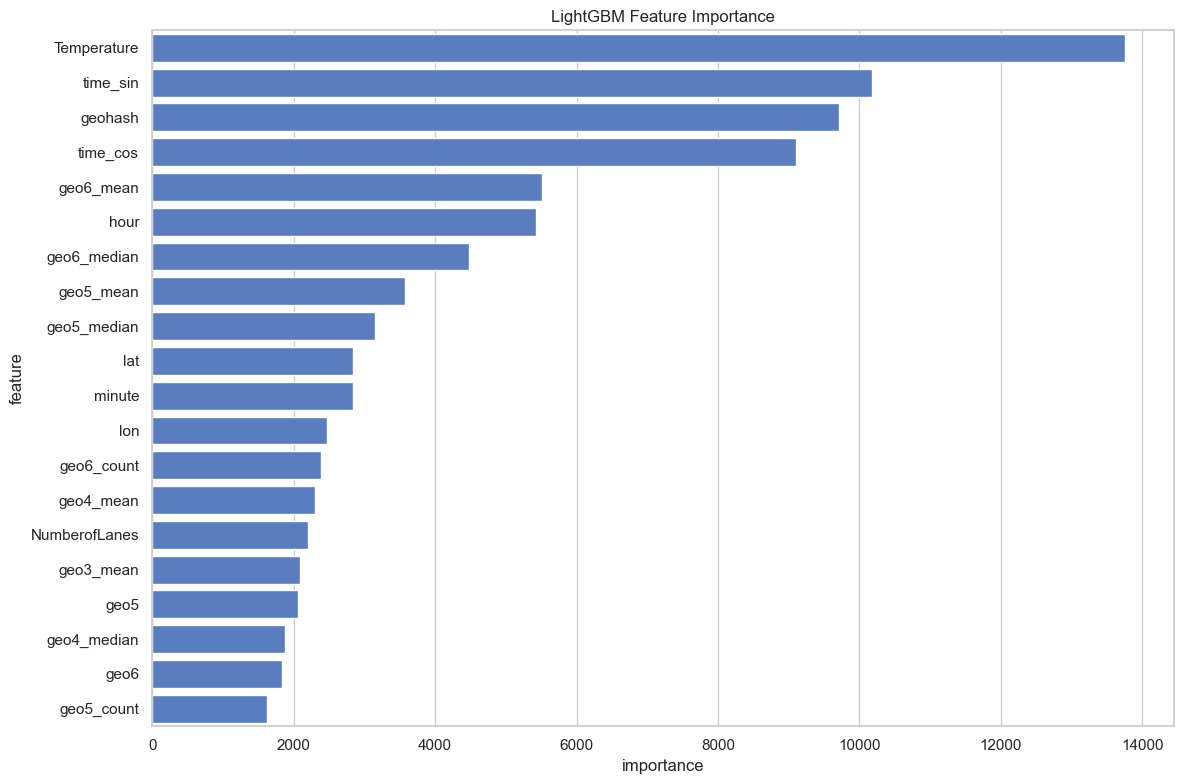

In [13]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='importance',
    ascending=False
)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=importance_df.head(20),
    x='importance',
    y='feature'
)

plt.title("LightGBM Feature Importance")
plt.tight_layout()
plt.show()

### CatBoost Model

In [14]:
cat_cols = ['RoadType','Weather','geohash','geo3','geo4','geo5','geo6','day_of_week']

cat_features = [X_train.columns.get_loc(c)for c in cat_cols]

cat_oof_log = np.zeros(len(X_train))
cat_test_log = np.zeros(len(X_test))

print("\nTraining CatBoost...\n")

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train), 1):

    print(f"CatBoost Fold {fold}")

    model = CatBoostRegressor(
        iterations=5000,
        learning_rate=0.03,
        depth=8,
        loss_function='RMSE',
        eval_metric='RMSE',
        random_seed=42,
        verbose=False
    )

    model.fit(
        X_train.iloc[tr_idx],
        y_train_log.iloc[tr_idx],
        eval_set=(X_train.iloc[val_idx],y_train_log.iloc[val_idx]),
        cat_features=cat_features,
        use_best_model=True
    )

    cat_oof_log[val_idx] = model.predict(X_train.iloc[val_idx])
    cat_test_log += (model.predict(X_test) / kf.n_splits)

cat_oof = np.expm1(cat_oof_log)
cat_test = np.expm1(cat_test_log)


Training CatBoost...

CatBoost Fold 1
CatBoost Fold 2
CatBoost Fold 3
CatBoost Fold 4
CatBoost Fold 5


#### Determine Importance

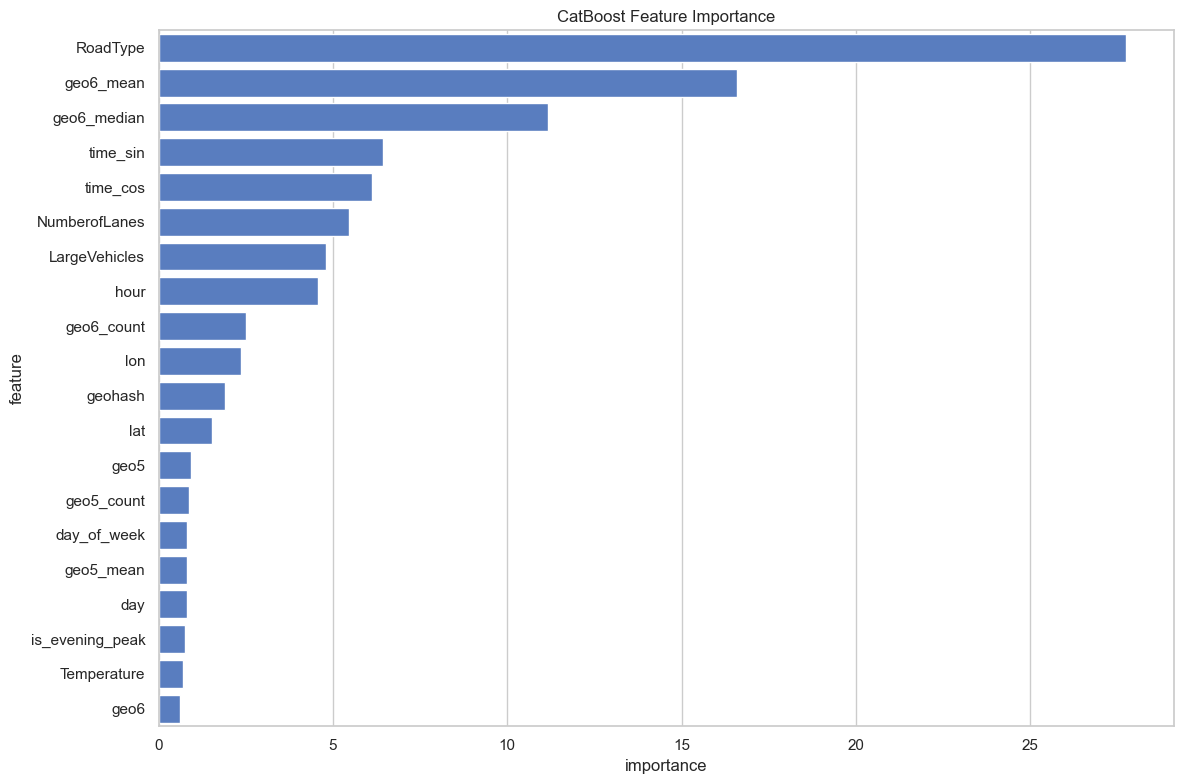

In [15]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.get_feature_importance()
})

importance_df = importance_df.sort_values(
    by='importance',
    ascending=False
)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=importance_df.head(20),
    x='importance',
    y='feature'
)

plt.title("CatBoost Feature Importance")
plt.tight_layout()
plt.show()

## Prediction & Submission

In [16]:
# Ensemble predictions with a weighted average
weight = 0.585 # found via hit and trial
final_preds = (weight * lgb_test + (1 - weight) * cat_test)

In [17]:
# Create submission file
submission = pd.DataFrame({'Index': test['Index'],'demand': final_preds})
submission.to_csv('submission.csv',index=False)
print("\nSaved: submission.csv")


Saved: submission.csv
